In [40]:
# ------------Task 1: Data Loading & Inspection-----------

import pandas as pd
import numpy as np

# Load dataset
file_path = "SpotifY_DataSet1.csv"
df = pd.read_csv(file_path)

# Preview dataset
print("First 5 rows:\n")
display(df.head())

# Dataset structure
print("\nDataset Info:\n")
df.info()

# Statistical summary
print("\nStatistical Description:\n")
display(df.describe())

# Missing values using NumPy/Pandas
print("\nMissing Values in Each Column:\n")
print(np.sum(df.isnull(), axis=0))



First 5 rows:



,track_no,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min_sec
0,1,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50.0,False,0.369,0.598,7.0,...,1.0,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4.0,world-music,07:20
1,2,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11.0,False,0.171,0.997,7.0,...,1.0,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4.0,grindcore,01:33
2,3,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0.0,False,0.173,0.803,9.0,...,0.0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3.0,iranian,03:33
3,4,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0.0,False,0.683,0.511,6.0,...,1.0,0.0279,0.40600,0.000197,0.111,0.5980,NaN,3.0,rock,02:31
4,5,NaN,Nogizaka46,TypeD,NaN,57.0,False,0.555,0.941,9.0,...,0.0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4.0,j-idol,03:56



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_no          500 non-null    int64  
 1   track_id          494 non-null    object 
 2   artists           496 non-null    object 
 3   album_name        485 non-null    object 
 4   track_name        480 non-null    object 
 5   popularity        495 non-null    float64
 6   explicit          490 non-null    object 
 7   danceability      494 non-null    float64
 8   energy            496 non-null    float64
 9   key               493 non-null    float64
 10  loudness          495 non-null    float64
 11  mode              496 non-null    float64
 12  speechiness       497 non-null    float64
 13  acousticness      496 non-null    float64
 14  instrumentalness  495 non-null    float64
 15  liveness          490 non-null    float64
 16  valence           494 non-nu

,track_no,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,500.000000,495.000000,494.000000,496.000000,493.000000,495.000000,496.000000,497.000000,496.000000,495.000000,490.000000,494.000000,497.000000,490.000000
mean,250.500000,33.840404,0.563591,0.646689,5.312373,-7.928521,0.633065,0.091659,0.314151,0.123651,0.218453,0.474377,125.129109,3.934694
std,144.481833,22.859472,0.182916,0.248024,3.589703,4.442022,0.482455,0.116451,0.326767,0.279317,0.185898,0.263211,29.340796,0.399156
min,1.000000,0.000000,0.000000,0.000020,0.000000,-32.364000,0.000000,0.000000,0.000002,0.000000,0.018900,0.000000,0.000000,0.000000
25%,125.750000,16.500000,0.456250,0.477750,2.000000,-9.537000,0.000000,0.035800,0.017775,0.000000,0.102000,0.256500,102.741000,4.000000
50%,250.500000,35.000000,0.580500,0.688500,5.000000,-6.955000,1.000000,0.051800,0.180500,0.000034,0.141000,0.474500,123.222000,4.000000
75%,375.250000,51.000000,0.704750,0.857500,8.000000,-4.898000,1.000000,0.095100,0.592500,0.010650,0.292500,0.667000,145.005000,4.000000
max,500.000000,87.000000,0.917000,0.999000,11.000000,-0.332000,1.000000,0.959000,0.993000,0.965000,0.988000,0.992000,203.006000,5.000000



Missing Values in Each Column:

track_no             0
track_id             6
artists              4
album_name          15
track_name          20
popularity           5
explicit            10
danceability         6
energy               4
key                  7
loudness             5
mode                 4
speechiness          3
acousticness         4
instrumentalness     5
liveness            10
valence              6
tempo                3
time_signature      10
track_genre          7
duration_min_sec     5
dtype: int64


In [41]:
# --------- TASK 2 : DATA CLEANING ----------

df_cleaned = df.copy()

print("Initial Shape of Dataset:", df_cleaned.shape)

# 1. Handling Missing Values

# Fill numeric columns with mean
numeric_columns = df_cleaned.select_dtypes(include=["int64", "float64"]).columns
df_cleaned[numeric_columns] = df_cleaned[numeric_columns].fillna(df_cleaned[numeric_columns].mean())

# Fill categorical columns with mode
categorical_columns = df_cleaned.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("\nMissing Values After Cleaning:\n")
print(df_cleaned.isnull().sum())

# 2. Removing Duplicate Records
duplicates_before = df_cleaned.duplicated().sum()
df_cleaned = df_cleaned.drop_duplicates()
duplicates_after = df_cleaned.duplicated().sum()

print("\nDuplicate Records Before Cleaning:", duplicates_before)
print("Duplicate Records After Cleaning:", duplicates_after)

print("\nFinal Shape of Dataset After Cleaning:", df_cleaned.shape)

# Preview cleaned data
display(df_cleaned.head())


Initial Shape of Dataset: (500, 21)

Missing Values After Cleaning:

track_no            0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
duration_min_sec    0
dtype: int64

Duplicate Records Before Cleaning: 0
Duplicate Records After Cleaning: 0

Final Shape of Dataset After Cleaning: (500, 21)


C:\Users\Jnapikachowdary\AppData\Local\Temp\ipykernel_2016\4233864454.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])


,track_no,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min_sec
0,1,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50.0,False,0.369,0.598,7.0,...,1.0,0.0304,0.00511,0.000000,0.176,0.0466,148.014000,4.0,world-music,07:20
1,2,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11.0,False,0.171,0.997,7.0,...,1.0,0.1180,0.00521,0.801000,0.420,0.0294,122.223000,4.0,grindcore,01:33
2,3,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0.0,False,0.173,0.803,9.0,...,0.0,0.1440,0.61300,0.001910,0.195,0.0887,75.564000,3.0,iranian,03:33
3,4,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0.0,False,0.683,0.511,6.0,...,1.0,0.0279,0.40600,0.000197,0.111,0.5980,125.129109,3.0,rock,02:31
4,5,6JN0cjFT0zDRYxzqcKrvwf,Nogizaka46,TypeD,,57.0,False,0.555,0.941,9.0,...,0.0,0.0481,0.48400,0.000000,0.266,0.8130,92.487000,4.0,j-idol,03:56


In [42]:
# --------- TASK 3 : DATA WRANGLING ----------

print("Initial Data Types:\n")
print(df_cleaned.dtypes)

# 1. Convert Data Types Automatically
df_cleaned = df_cleaned.convert_dtypes()

print("\nUpdated Data Types After Conversion:\n")
print(df_cleaned.dtypes)

# 2. Create Derived Column: Popularity Level

df_cleaned["Popularity_Level"] = pd.cut(
    df_cleaned["popularity"],
    bins=[-1, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

print("\nDerived Column 'Popularity_Level' Created Successfully!")

# 3. Normalize Selected Numeric Columns

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalize_cols = ["danceability", "energy", "tempo", "valence"]

df_cleaned[[col + "_norm" for col in normalize_cols]] = scaler.fit_transform(
    df_cleaned[normalize_cols]
)

print("\nNormalized Columns Added:")
print([col + "_norm" for col in normalize_cols])

# 4. Encode Categorical Column (Artists)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_cleaned["artists_encoded"] = encoder.fit_transform(df_cleaned["artists"])

print("\nEncoded Column 'artists_encoded' Created Successfully!")

# Preview Wrangled Dataset
print("\nPreview of Wrangled Dataset:\n")
display(df_cleaned.head())


Initial Data Types:

track_no              int64
track_id             object
artists              object
album_name           object
track_name           object
popularity          float64
explicit               bool
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_genre          object
duration_min_sec     object
dtype: object

Updated Data Types After Conversion:

track_no                     Int64
track_id            string[python]
artists             string[python]
album_name          string[python]
track_name          string[python]
popularity                 Float64
explicit                   boolean
danceability               Float64
energy                     Float64
key                    

,track_no,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,...,tempo,time_signature,track_genre,duration_min_sec,Popularity_Level,danceability_norm,energy_norm,tempo_norm,valence_norm,artists_encoded
0,1,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50.0,False,0.369,0.598,7.0,...,148.014,4.0,world-music,07:20,Medium,0.402399,0.598590,0.729111,0.046976,185
1,2,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11.0,False,0.171,0.997,7.0,...,122.223,4.0,grindcore,01:33,Low,0.186478,0.997998,0.602066,0.029637,189
2,3,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0.0,False,0.173,0.803,9.0,...,75.564,3.0,iranian,03:33,Low,0.188659,0.803800,0.372225,0.089415,458
3,4,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0.0,False,0.683,0.511,6.0,...,125.129109,3.0,rock,02:31,Low,0.744820,0.511502,0.616381,0.602823,77
4,5,6JN0cjFT0zDRYxzqcKrvwf,Nogizaka46,TypeD,,57.0,False,0.555,0.941,9.0,...,92.487,4.0,j-idol,03:56,Medium,0.605234,0.941941,0.455588,0.819556,299


In [37]:
# --------- TASK 4 : FILTERING & INDEXING ----------
import pandas as pd
import numpy as np

# Load dataset
file_path = "SpotifY_DataSet1.csv"
df = pd.read_csv(file_path)
df_cleaned = df.copy()
print("Original Dataset Shape:", df_cleaned.shape)

# 1. Filtering Based on Condition (High Popularity Songs)

high_popularity_tracks = df_cleaned.loc[
    df_cleaned["popularity"] > 70,
    ["track_name", "popularity"]
]


print("\nNumber of Songs with Popularity > 70:", high_popularity_tracks.shape[0])

print("\nPreview of Highly Popular Tracks:\n")
display(high_popularity_tracks.head())

# 2. Setting a Meaningful Index

df_cleaned.set_index("track_id", inplace=True)

print("\nIndex Successfully Set to 'track_id'")

print("\nUpdated Dataset Shape After Indexing:", df_cleaned.shape)

# Verify Index
print("\nNew Index Preview:\n")
print(df_cleaned.index[:5])


Original Dataset Shape: (500, 21)

Number of Songs with Popularity > 70: 27

Preview of Highly Popular Tracks:



,track_name,popularity
18,Into Your Arms (feat. Ava Max),77.0
31,Paris,74.0
42,Get It On,71.0
46,Yo No Soy Celoso,85.0
86,Stayin' Alive,77.0



Index Successfully Set to 'track_id'

Updated Dataset Shape After Indexing: (500, 20)

New Index Preview:

Index(['6KwkVtXm8OUp2XffN5k7lY', '2dp5I5MJ8bQQHDoFaNRFtX',
       '5avw06usmFkFrPjX8NxC40', '75hT0hvlESnDJstem0JgyR',
                            nan],
      dtype='object', name='track_id')


In [43]:
# --------- TASK 5 : AGGREGATION & GROUPING ----------

# 1. Group by Artist and Calculate Mean Popularity & Track Count

artist_group = df_cleaned.groupby("artists")["popularity"].agg(["mean", "count"])
artist_group = artist_group.sort_values(by="mean", ascending=False)

print("\nTop 10 Artists by Average Popularity:\n")
display(artist_group.head(10))


# 2. Group by Popularity Level and Compute Mean Audio Features
# observed=False added to remove FutureWarning

popularity_feature_group = df_cleaned.groupby(
    "Popularity_Level", observed=False
)[["danceability", "energy", "tempo", "valence"]].mean()

print("\nMean Audio Features by Popularity Level:\n")
display(popularity_feature_group)



Top 10 Artists by Average Popularity:



,mean,count
artists,,
Paloma Faith,87.0,1
Bad Bunny,85.0,1
Daddy Yankee;Bad Bunny,85.0,1
Adele,82.0,1
Sia,81.0,1
Alesso;Katy Perry,80.0,1
Nirvana,79.0,1
Bee Gees,77.0,1
Witt Lowry;Ava Max,77.0,1



Mean Audio Features by Popularity Level:



,danceability,energy,tempo,valence
Popularity_Level,,,,
Low,0.553022,0.651695,125.940622,0.487037
Medium,0.567824,0.625851,123.740267,0.451147
High,0.650059,0.731285,125.58163,0.491852


TASK-6 SPOTIFY VISUALIZATION STARTED


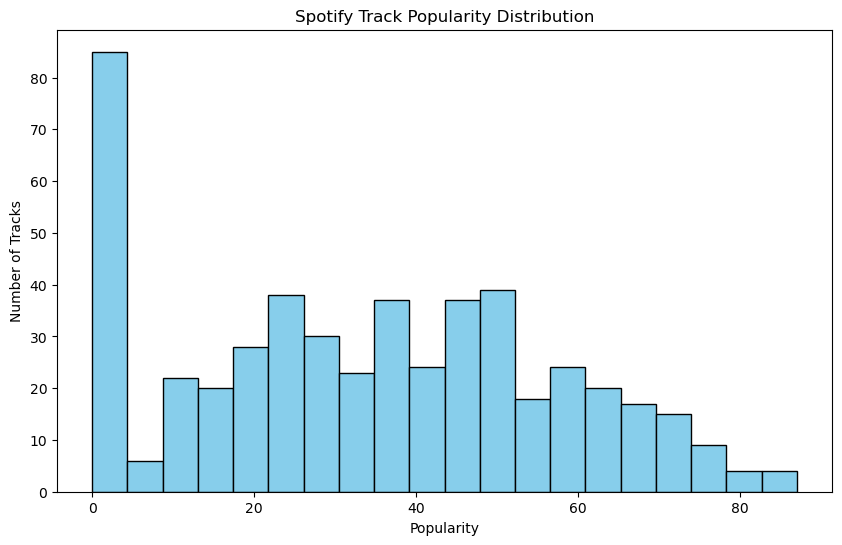

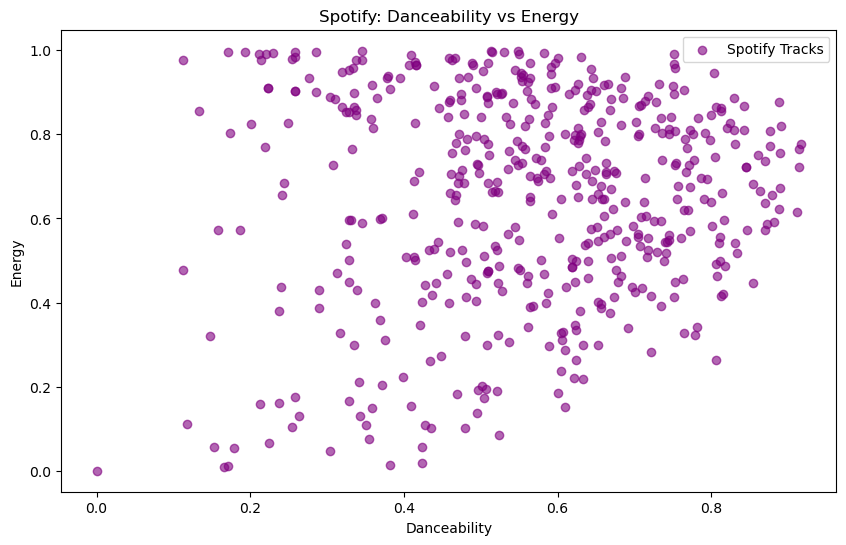

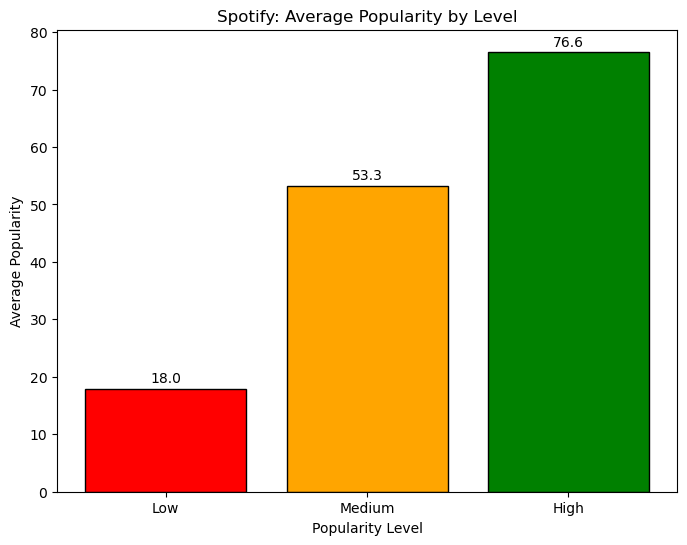

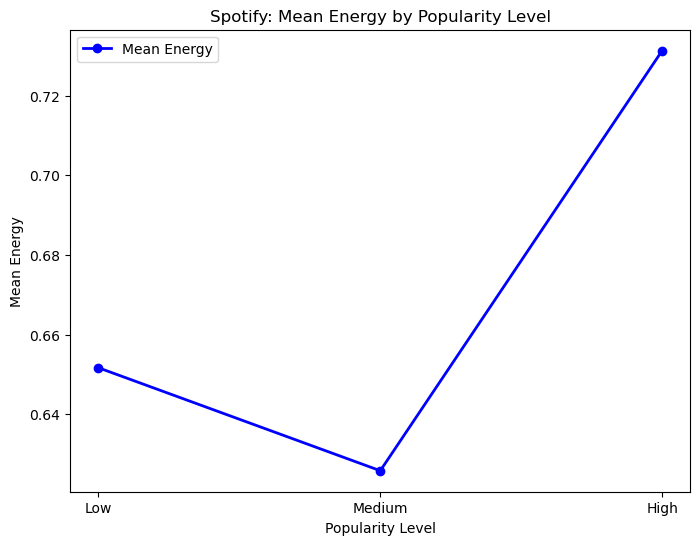

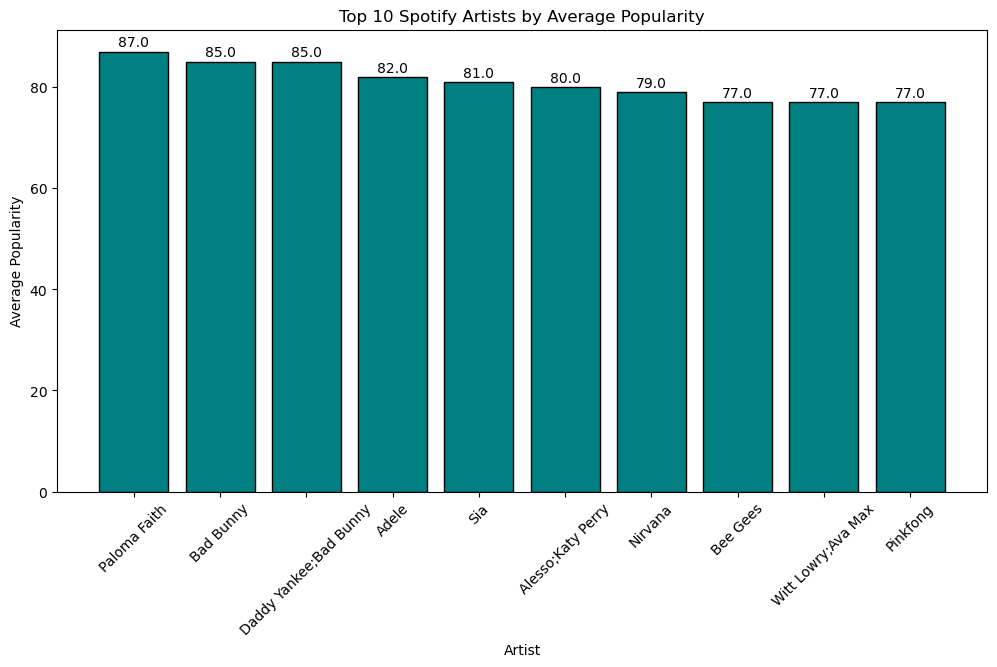

✅ All visualizations generated successfully!


In [44]:

#----------TASK 6 – VISUALIZATION ------------

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# LOAD YOUR SPOTIFY DATASET
# -------------------------------
df = pd.read_csv("SpotifY_DataSet1.csv")

# -------------------------------
# BASIC CLEANING FOR VISUALIZATION
# -------------------------------
df["popularity"] = df["popularity"].fillna(df["popularity"].mean())
df["danceability"] = df["danceability"].fillna(df["danceability"].mean())
df["energy"] = df["energy"].fillna(df["energy"].mean())

# Create Popularity Level for Spotify Data
df["Popularity_Level"] = pd.cut(
    df["popularity"],
    bins=[-1, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

print("TASK-6 SPOTIFY VISUALIZATION STARTED")

# ----------------------------------
# 1. HISTOGRAM – SPOTIFY POPULARITY
# ----------------------------------
plt.figure(figsize=(10, 6))
plt.hist(df["popularity"], bins=20, color="skyblue", edgecolor="black")
plt.title("Spotify Track Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.show()

# ----------------------------------
# 2. SCATTER – DANCEABILITY vs ENERGY
# ----------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df["danceability"], df["energy"], color="purple", alpha=0.6, label="Spotify Tracks")
plt.title("Spotify: Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.legend()
plt.show()

# --------------------------------
# 3. BAR CHART – AVG POPULARITY BY LEVEL
# --------------------------------
avg_popularity = df.groupby("Popularity_Level", observed=False)["popularity"].mean()

plt.figure(figsize=(8, 6))
plt.bar(
    avg_popularity.index.astype(str),
    avg_popularity.values,
    color=["red", "orange", "green"],
    edgecolor="black"
)
plt.title("Spotify: Average Popularity by Level")
plt.xlabel("Popularity Level")
plt.ylabel("Average Popularity")

for i, v in enumerate(avg_popularity.values):
    plt.text(i, v + 1, f"{v:.1f}", ha="center")

plt.show()

# --------------------------------
# 4. LINE CHART – MEAN ENERGY BY LEVEL
# --------------------------------
mean_energy = df.groupby("Popularity_Level", observed=False)["energy"].mean()

plt.figure(figsize=(8, 6))
plt.plot(
    mean_energy.index.astype(str),
    mean_energy.values,
    marker="o",
    color="blue",
    linewidth=2,
    label="Mean Energy"
)
plt.title("Spotify: Mean Energy by Popularity Level")
plt.xlabel("Popularity Level")
plt.ylabel("Mean Energy")
plt.legend()
plt.show()

# --------------------------------
# 5. BAR CHART – TOP 10 SPOTIFY ARTISTS
# --------------------------------
top_artists = (
    df.groupby("artists")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.bar(top_artists.index, top_artists.values, color="teal", edgecolor="black")
plt.title("Top 10 Spotify Artists by Average Popularity")
plt.xlabel("Artist")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)

for i, v in enumerate(top_artists.values):
    plt.text(i, v + 1, f"{v:.1f}", ha="center")

plt.show()

# ✅ FINAL SUCCESS MESSAGE
print("✅ All visualizations generated successfully!")


In [22]:
# --------- TASK 5 : AGGREGATION & GROUPING ----------

# 1. Group by Artist and Calculate Mean Popularity & Track Count
artist_group = df_cleaned.groupby("artists")["popularity"].agg(["mean", "count"])
artist_group = artist_group.sort_values(by="mean", ascending=False)

print("\nTop 10 Artists by Average Popularity:\n")
display(artist_group.head(10))


# 2. Create Popularity_Level if not created earlier
df_cleaned["Popularity_Level"] = pd.cut(
    df_cleaned["popularity"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)


# 3. Group by Popularity Level and Compute Mean Audio Features
popularity_feature_group = df_cleaned.groupby(
    "Popularity_Level"
)[["danceability", "energy", "tempo", "valence"]].mean()

print("\nMean Audio Features by Popularity Level:\n")
display(popularity_feature_group)



Top 10 Artists by Average Popularity:



,mean,count
artists,,
Paloma Faith,87.0,1
Bad Bunny,85.0,1
Daddy Yankee;Bad Bunny,85.0,1
Adele,82.0,1
Sia,81.0,1
Alesso;Katy Perry,80.0,1
Nirvana,79.0,1
Bee Gees,77.0,1
Rammstein,77.0,1



Mean Audio Features by Popularity Level:



C:\Users\Jnapikachowdary\AppData\Local\Temp\ipykernel_2016\894197779.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  popularity_feature_group = df_cleaned.groupby(


,danceability,energy,tempo,valence
Popularity_Level,,,,
Low,0.546458,0.646591,125.622360,0.474679
Medium,0.567920,0.625734,123.732508,0.451017
High,0.653385,0.734538,125.581630,0.491852
